In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


In [2]:
pasta_dados = '../dados/dados_processados/zero_day/'

df_predicoes = pd.read_csv(os.path.join(pasta_dados, 'predicoes_zero_day.csv'))
df_tempos    = pd.read_csv(os.path.join(pasta_dados, 'tempos_inferencia.csv'))

print(f"DataFrame de predições: {df_predicoes.shape}")
print(f"DataFrame de tempos:    {df_tempos.shape}")

print(f"\nColunas de predição: {[c for c in df_predicoes.columns if c != 'Label_real']}")
print(f"\nDistribuição real (zero-day):")
for classe, qtd in df_predicoes['Label_real'].value_counts().items():
    pct = (qtd / len(df_predicoes)) * 100
    print(f"  {classe:20s} → {qtd:>4} ({pct:.2f}%)")

DataFrame de predições: (147, 13)
DataFrame de tempos:    (12, 3)

Colunas de predição: ['RF_original', 'RF_pca', 'RF_lda', 'XGB_original', 'XGB_pca', 'XGB_lda', 'IF_original', 'IF_pca', 'IF_lda', 'MS_original', 'MS_pca', 'MS_lda']

Distribuição real (zero-day):
  BENIGN               →  100 (68.03%)
  Infiltration         →   36 (24.49%)
  Heartbleed           →   11 (7.48%)


In [3]:
# Como o cenário é zero-day, o que importa é detectar ataque, não classificar exatamente.
# Transformamos tudo em binário: ATAQUE (1) ou BENIGNO (0)

def para_binario_real(label):
    """Label real: BENIGN → 0 (BENIGNO); Heartbleed/Infiltration → 1 (ATAQUE)"""
    return 0 if label == 'BENIGN' else 1


def para_binario_predito(pred):
    """
    Predição:
      - 'BENIGN' ou 'NORMAL'  → 0 (BENIGNO)
      - Qualquer outra classe ou 'ANOMALIA' → 1 (ATAQUE)
    """
    return 0 if pred in ['BENIGN', 'NORMAL'] else 1


# aplicando no rótulo real
y_real_bin = df_predicoes['Label_real'].apply(para_binario_real).values

# aplicando em cada coluna de predição
colunas_modelos = [c for c in df_predicoes.columns if c != 'Label_real']
df_bin = pd.DataFrame({'y_real': y_real_bin})

for col in colunas_modelos:
    df_bin[col] = df_predicoes[col].apply(para_binario_predito).values

print("Conversão binária concluída ✅\n")
print(f"Distribuição real (binária):")
print(f"  BENIGNO (0): {(y_real_bin == 0).sum()} ({(y_real_bin==0).mean()*100:.2f}%)")
print(f"  ATAQUE  (1): {(y_real_bin == 1).sum()} ({(y_real_bin==1).mean()*100:.2f}%)")

print(f"\nPrimeiras 5 linhas (binário):")
print(df_bin.head())

Conversão binária concluída ✅

Distribuição real (binária):
  BENIGNO (0): 100 (68.03%)
  ATAQUE  (1): 47 (31.97%)

Primeiras 5 linhas (binário):
   y_real  RF_original  RF_pca  RF_lda  XGB_original  XGB_pca  XGB_lda  IF_original  IF_pca  IF_lda  MS_original  MS_pca  MS_lda
0       1            0       0       0             0        0        0            0       0       1            0       0       1
1       1            0       0       0             0        0        0            0       0       0            0       0       0
2       1            0       0       1             0        0        1            1       1       1            1       1       1
3       1            0       0       0             0        0        0            0       0       1            0       0       1
4       1            0       0       1             0        0        1            1       1       1            1       1       1


In [4]:
# para cada modelo, calculamos: acurácia, precisão, recall, F1, TP, FP, TN, FN
resultados_metricas = []

for col in colunas_modelos:
    y_pred = df_bin[col].values

    # decompondo nome da coluna (ex.: 'RF_original' → algoritmo='RF', versao='original')
    algoritmo, versao = col.split('_', 1)

    # matriz de confusão: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_real_bin, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_real_bin, y_pred)
    prec = precision_score(y_real_bin, y_pred, zero_division=0)
    rec = recall_score(y_real_bin, y_pred, zero_division=0)
    f1 = f1_score(y_real_bin, y_pred, zero_division=0)

    # taxa de falsos positivos (FP / (FP + TN))
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    # taxa de falsos negativos (FN / (FN + TP))
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    resultados_metricas.append({
        'Algoritmo':   algoritmo,
        'Versão':      versao.upper(),
        'Modelo':      col,
        'Acurácia':    acc,
        'Precisão':    prec,
        'Recall':      rec,
        'F1-Score':    f1,
        'FPR':         fpr,
        'FNR':         fnr,
        'TP':          tp,
        'FP':          fp,
        'TN':          tn,
        'FN':          fn,
    })

df_metricas = pd.DataFrame(resultados_metricas)

print("Métricas calculadas para os 12 modelos ✅\n")
print("=" * 110)
print(df_metricas[['Algoritmo','Versão','Acurácia','Precisão','Recall','F1-Score','FPR','FNR']]
      .to_string(index=False, float_format='%.4f'))
print("=" * 110)

Métricas calculadas para os 12 modelos ✅

Algoritmo   Versão  Acurácia  Precisão  Recall  F1-Score    FPR    FNR
       RF ORIGINAL    0.6803    0.0000  0.0000    0.0000 0.0000 1.0000
       RF      PCA    0.7347    0.8333  0.2128    0.3390 0.0200 0.7872
       RF      LDA    0.7687    0.8421  0.3404    0.4848 0.0300 0.6596
      XGB ORIGINAL    0.7211    1.0000  0.1277    0.2264 0.0000 0.8723
      XGB      PCA    0.7279    0.7333  0.2340    0.3548 0.0400 0.7660
      XGB      LDA    0.7755    0.8182  0.3830    0.5217 0.0400 0.6170
       IF ORIGINAL    0.8231    0.6721  0.8723    0.7593 0.2000 0.1277
       IF      PCA    0.7823    0.6087  0.8936    0.7241 0.2700 0.1064
       IF      LDA    0.7211    0.5375  0.9149    0.6772 0.3700 0.0851
       MS ORIGINAL    0.8163    0.6724  0.8298    0.7429 0.1900 0.1702
       MS      PCA    0.8639    0.7455  0.8723    0.8039 0.1400 0.1277
       MS      LDA    0.3469    0.3212  0.9362    0.4783 0.9300 0.0638


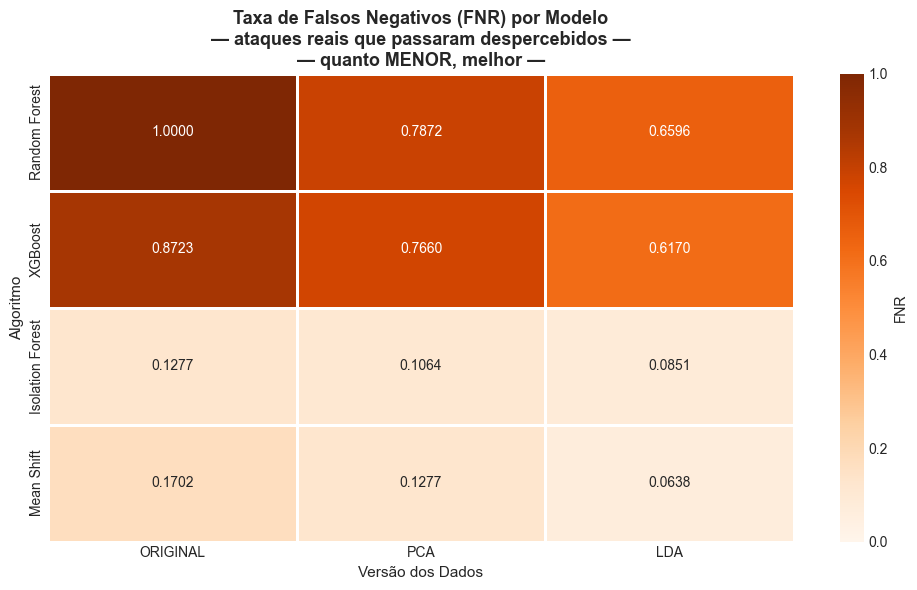


📊 Pivot FNR:
Versão              ORIGINAL     PCA     LDA
Algoritmo_Completo                          
Random Forest         1.0000  0.7872  0.6596
XGBoost               0.8723  0.7660  0.6170
Isolation Forest      0.1277  0.1064  0.0851
Mean Shift            0.1702  0.1277  0.0638


In [5]:
# Heatmap da Taxa de Falsos Negativos (FNR)
nomes_algoritmo = {
    'RF':  'Random Forest',
    'XGB': 'XGBoost',
    'IF':  'Isolation Forest',
    'MS':  'Mean Shift'
}
df_metricas['Algoritmo_Completo'] = df_metricas['Algoritmo'].map(nomes_algoritmo)

pivot_fnr = df_metricas.pivot(index='Algoritmo_Completo', columns='Versão', values='FNR')
pivot_fnr = pivot_fnr[['ORIGINAL', 'PCA', 'LDA']]
pivot_fnr = pivot_fnr.reindex(['Random Forest', 'XGBoost', 'Isolation Forest', 'Mean Shift'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_fnr, annot=True, fmt='.4f', cmap='Oranges',
            vmin=0, vmax=1, cbar_kws={'label': 'FNR'},
            linewidths=1, linecolor='white', ax=ax)
ax.set_title('Taxa de Falsos Negativos (FNR) por Modelo\n'
             '— ataques reais que passaram despercebidos —\n'
             '— quanto MENOR, melhor —',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Versão dos Dados', fontsize=11)
ax.set_ylabel('Algoritmo', fontsize=11)
plt.tight_layout()
plt.show()

print("\n📊 Pivot FNR:")
print(pivot_fnr.round(4))


In [6]:
# nomes completos para usar nos gráficos
nomes_algoritmo = {
    'RF':  'Random Forest',
    'XGB': 'XGBoost',
    'IF':  'Isolation Forest',
    'MS':  'Mean Shift'
}

df_metricas['Algoritmo_Completo'] = df_metricas['Algoritmo'].map(nomes_algoritmo)

print("Mapeamento aplicado ✅")
print(df_metricas[['Algoritmo','Algoritmo_Completo','Versão']].head(12))

Mapeamento aplicado ✅
   Algoritmo Algoritmo_Completo    Versão
0         RF      Random Forest  ORIGINAL
1         RF      Random Forest       PCA
2         RF      Random Forest       LDA
3        XGB            XGBoost  ORIGINAL
4        XGB            XGBoost       PCA
5        XGB            XGBoost       LDA
6         IF   Isolation Forest  ORIGINAL
7         IF   Isolation Forest       PCA
8         IF   Isolation Forest       LDA
9         MS         Mean Shift  ORIGINAL
10        MS         Mean Shift       PCA
11        MS         Mean Shift       LDA


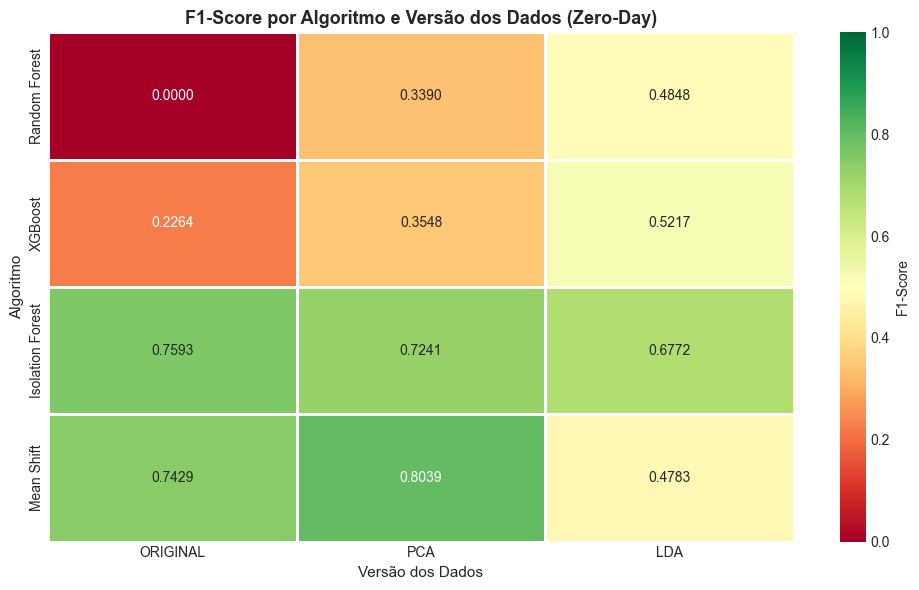


📊 Pivot F1-Score:
Versão              ORIGINAL     PCA     LDA
Algoritmo_Completo                          
Random Forest         0.0000  0.3390  0.4848
XGBoost               0.2264  0.3548  0.5217
Isolation Forest      0.7593  0.7241  0.6772
Mean Shift            0.7429  0.8039  0.4783


In [7]:
# pivot para ter algoritmos nas linhas e versões nas colunas
pivot_f1 = df_metricas.pivot(index='Algoritmo_Completo', columns='Versão', values='F1-Score')
pivot_f1 = pivot_f1[['ORIGINAL', 'PCA', 'LDA']]  # ordem fixa
pivot_f1 = pivot_f1.reindex(['Random Forest', 'XGBoost', 'Isolation Forest', 'Mean Shift'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'F1-Score'},
            linewidths=1, linecolor='white', ax=ax)
ax.set_title('F1-Score por Algoritmo e Versão dos Dados (Zero-Day)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Versão dos Dados', fontsize=11)
ax.set_ylabel('Algoritmo', fontsize=11)
plt.tight_layout()
plt.show()

print("\n📊 Pivot F1-Score:")
print(pivot_f1.round(4))

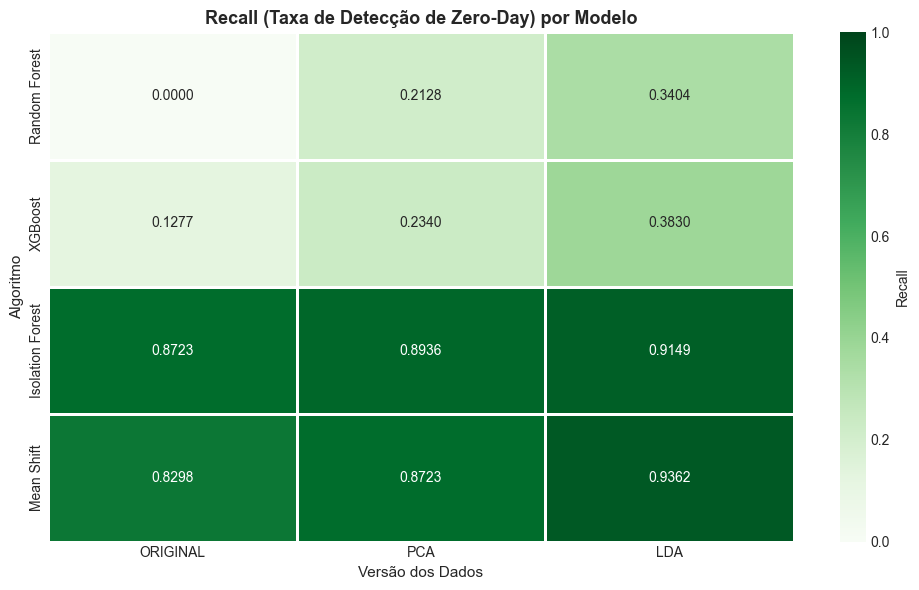


📊 Pivot Recall:
Versão              ORIGINAL     PCA     LDA
Algoritmo_Completo                          
Random Forest         0.0000  0.2128  0.3404
XGBoost               0.1277  0.2340  0.3830
Isolation Forest      0.8723  0.8936  0.9149
Mean Shift            0.8298  0.8723  0.9362


In [8]:
pivot_rec = df_metricas.pivot(index='Algoritmo_Completo', columns='Versão', values='Recall')
pivot_rec = pivot_rec[['ORIGINAL', 'PCA', 'LDA']]
pivot_rec = pivot_rec.reindex(['Random Forest', 'XGBoost', 'Isolation Forest', 'Mean Shift'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_rec, annot=True, fmt='.4f', cmap='Greens',
            vmin=0, vmax=1, cbar_kws={'label': 'Recall'},
            linewidths=1, linecolor='white', ax=ax)
ax.set_title('Recall (Taxa de Detecção de Zero-Day) por Modelo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Versão dos Dados', fontsize=11)
ax.set_ylabel('Algoritmo', fontsize=11)
plt.tight_layout()
plt.show()

print("\n📊 Pivot Recall:")
print(pivot_rec.round(4))

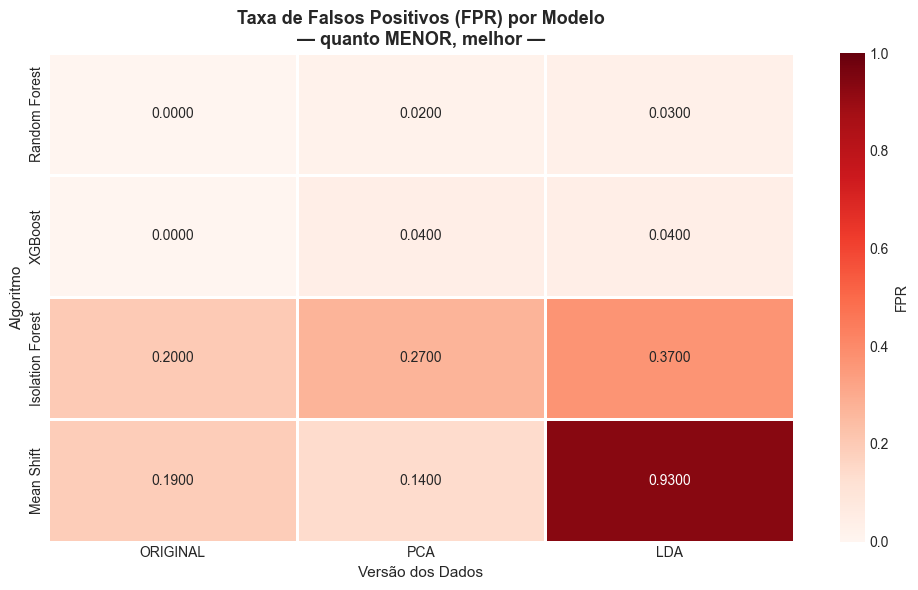


📊 Pivot FPR:
Versão              ORIGINAL   PCA   LDA
Algoritmo_Completo                      
Random Forest           0.00  0.02  0.03
XGBoost                 0.00  0.04  0.04
Isolation Forest        0.20  0.27  0.37
Mean Shift              0.19  0.14  0.93


In [9]:
pivot_fpr = df_metricas.pivot(index='Algoritmo_Completo', columns='Versão', values='FPR')
pivot_fpr = pivot_fpr[['ORIGINAL', 'PCA', 'LDA']]
pivot_fpr = pivot_fpr.reindex(['Random Forest', 'XGBoost', 'Isolation Forest', 'Mean Shift'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_fpr, annot=True, fmt='.4f', cmap='Reds',
            vmin=0, vmax=1, cbar_kws={'label': 'FPR'},
            linewidths=1, linecolor='white', ax=ax)
ax.set_title('Taxa de Falsos Positivos (FPR) por Modelo\n— quanto MENOR, melhor —',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Versão dos Dados', fontsize=11)
ax.set_ylabel('Algoritmo', fontsize=11)
plt.tight_layout()
plt.show()

print("\n📊 Pivot FPR:")
print(pivot_fpr.round(4))

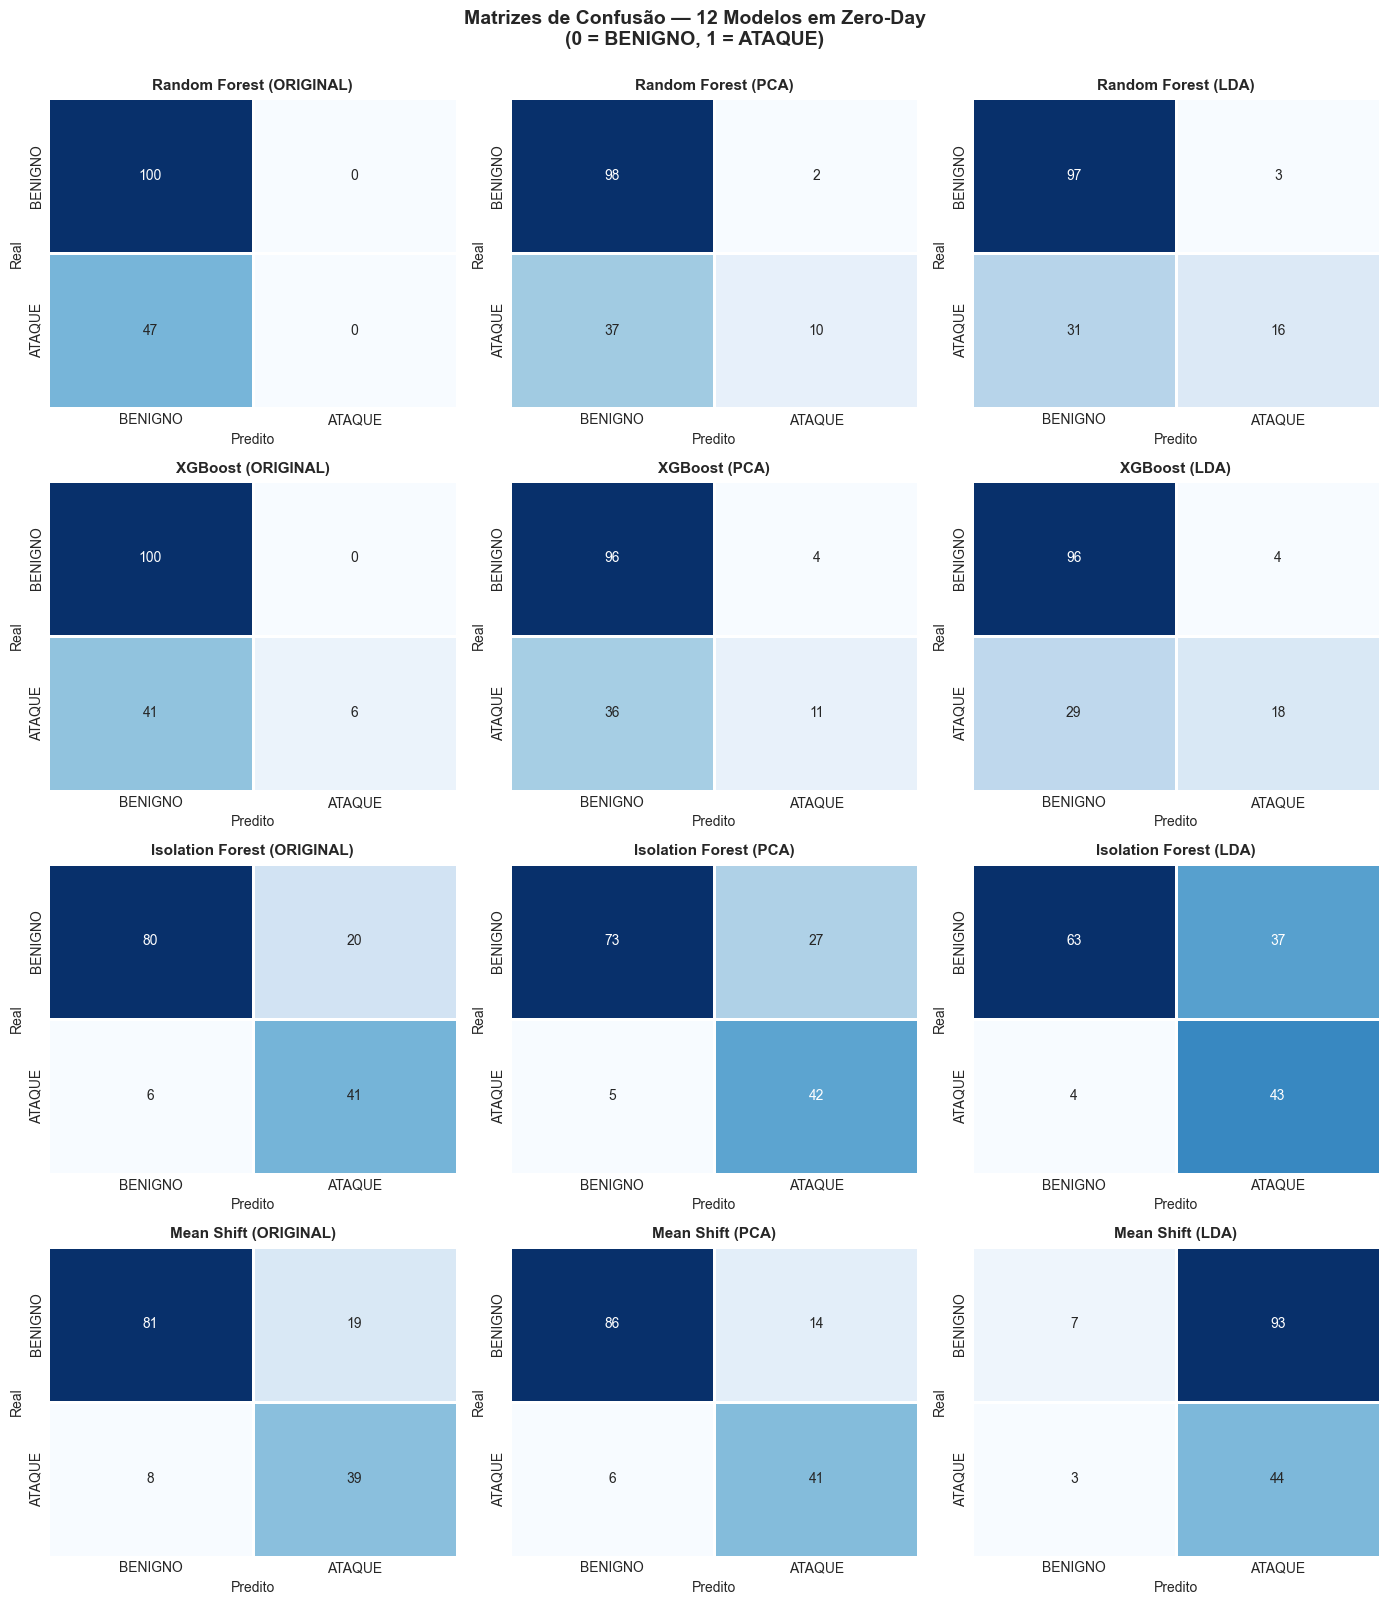

In [10]:
fig, axes = plt.subplots(4, 3, figsize=(14, 16))
fig.suptitle('Matrizes de Confusão — 12 Modelos em Zero-Day\n(0 = BENIGNO, 1 = ATAQUE)',
             fontsize=14, fontweight='bold', y=1.00)

ordem_algos = ['RF', 'XGB', 'IF', 'MS']
ordem_versoes = ['original', 'pca', 'lda']

for i, alg in enumerate(ordem_algos):
    for j, ver in enumerate(ordem_versoes):
        col = f'{alg}_{ver}'
        y_pred = df_bin[col].values
        cm = confusion_matrix(y_real_bin, y_pred, labels=[0, 1])

        ax = axes[i, j]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['BENIGNO', 'ATAQUE'],
                    yticklabels=['BENIGNO', 'ATAQUE'],
                    cbar=False, ax=ax, linewidths=1, linecolor='white')

        nome_alg = nomes_algoritmo[alg]
        ax.set_title(f'{nome_alg} ({ver.upper()})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predito', fontsize=10)
        ax.set_ylabel('Real', fontsize=10)

plt.tight_layout()
plt.show()

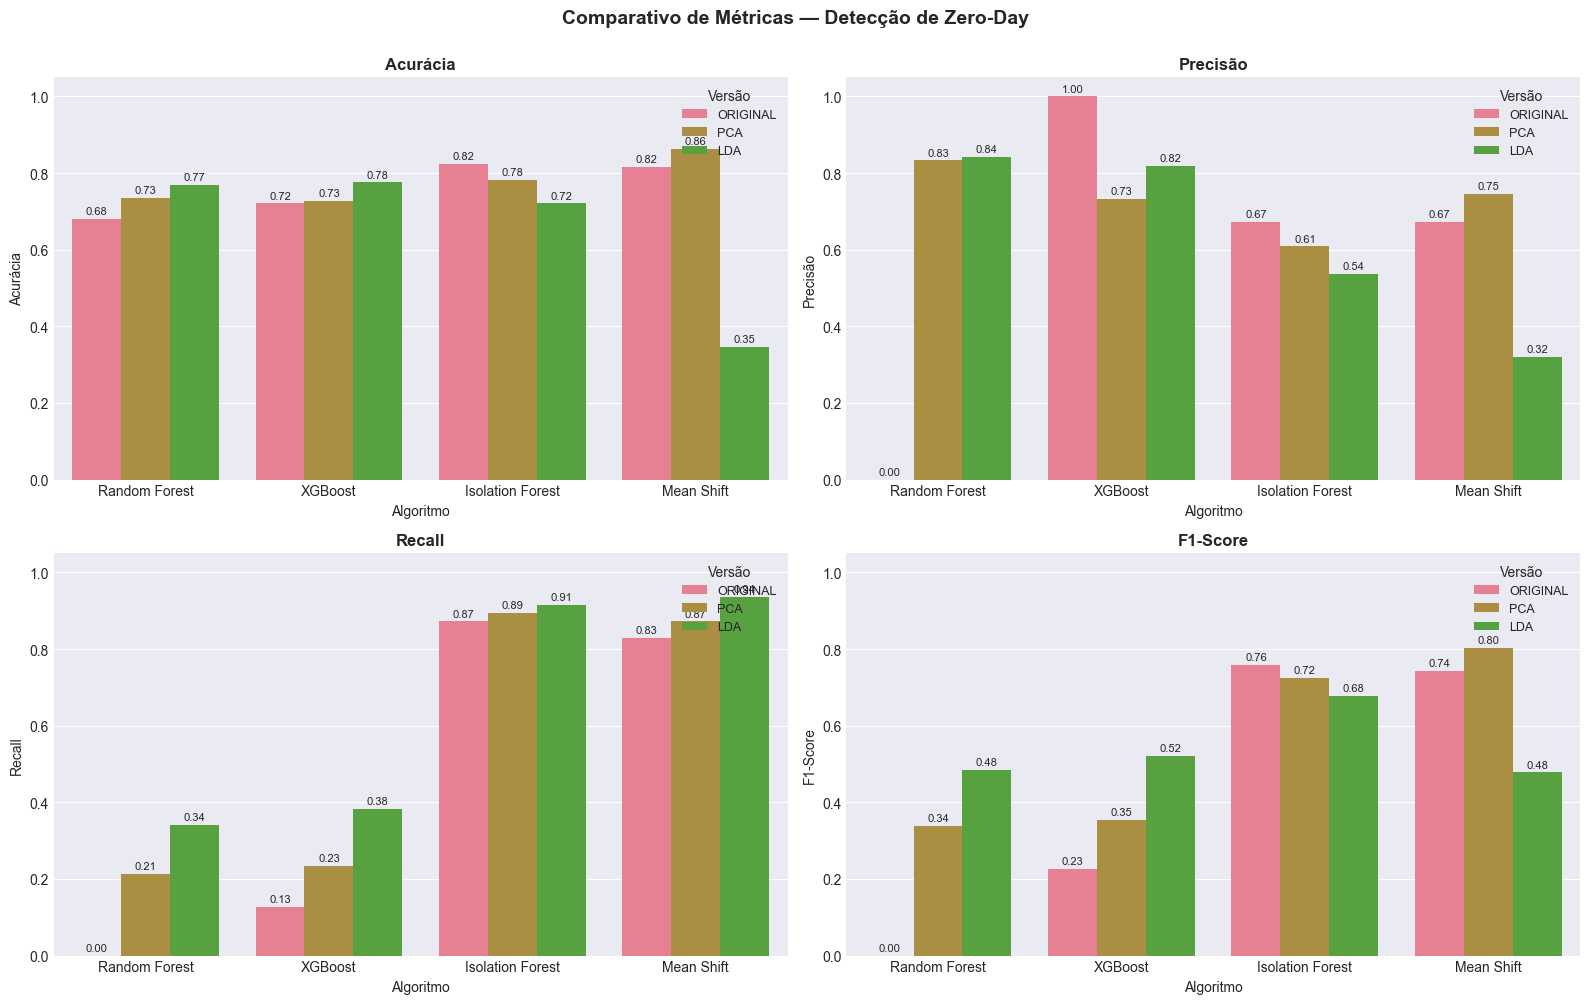

In [11]:
metricas_plot = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comparativo de Métricas — Detecção de Zero-Day',
             fontsize=14, fontweight='bold', y=1.00)

for idx, metrica in enumerate(metricas_plot):
    ax = axes[idx // 2, idx % 2]
    sns.barplot(data=df_metricas, x='Algoritmo_Completo', y=metrica,
                hue='Versão', ax=ax,
                hue_order=['ORIGINAL', 'PCA', 'LDA'],
                order=['Random Forest', 'XGBoost', 'Isolation Forest', 'Mean Shift'])

    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_xlabel('Algoritmo', fontsize=10)
    ax.set_ylabel(metrica, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.legend(title='Versão', loc='upper right', fontsize=9)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

In [12]:
ranking = df_metricas.sort_values('F1-Score', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1  # ranking começa em 1
ranking.index.name = 'Posição'

print("=" * 95)
print("            🏆 RANKING DOS 12 MODELOS — DETECÇÃO DE ZERO-DAY (por F1-Score)")
print("=" * 95)
print(ranking[['Algoritmo_Completo','Versão','Acurácia','Precisão','Recall','F1-Score','FPR']]
      .to_string(float_format='%.4f'))
print("=" * 95)

print(f"\n🥇 Melhor modelo geral:")
melhor = ranking.iloc[0]
print(f"   {melhor['Algoritmo_Completo']} ({melhor['Versão']})")
print(f"   F1-Score: {melhor['F1-Score']:.4f} | Recall: {melhor['Recall']:.4f} | "
      f"Precisão: {melhor['Precisão']:.4f} | FPR: {melhor['FPR']:.4f}")

            🏆 RANKING DOS 12 MODELOS — DETECÇÃO DE ZERO-DAY (por F1-Score)
        Algoritmo_Completo    Versão  Acurácia  Precisão  Recall  F1-Score    FPR
Posição                                                                          
1               Mean Shift       PCA    0.8639    0.7455  0.8723    0.8039 0.1400
2         Isolation Forest  ORIGINAL    0.8231    0.6721  0.8723    0.7593 0.2000
3               Mean Shift  ORIGINAL    0.8163    0.6724  0.8298    0.7429 0.1900
4         Isolation Forest       PCA    0.7823    0.6087  0.8936    0.7241 0.2700
5         Isolation Forest       LDA    0.7211    0.5375  0.9149    0.6772 0.3700
6                  XGBoost       LDA    0.7755    0.8182  0.3830    0.5217 0.0400
7            Random Forest       LDA    0.7687    0.8421  0.3404    0.4848 0.0300
8               Mean Shift       LDA    0.3469    0.3212  0.9362    0.4783 0.9300
9                  XGBoost       PCA    0.7279    0.7333  0.2340    0.3548 0.0400
10           Random For

In [13]:
# avaliando quantos Heartbleed e Infiltration cada modelo detectou como ATAQUE
print("=" * 90)
print("    📊 DETECÇÃO POR TIPO DE ZERO-DAY (quantos cada modelo identificou como ATAQUE)")
print("=" * 90)

mascara_heart = df_predicoes['Label_real'] == 'Heartbleed'
mascara_infil = df_predicoes['Label_real'] == 'Infiltration'

total_heart = mascara_heart.sum()
total_infil = mascara_infil.sum()

print(f"\nTotal de Heartbleed:   {total_heart}")
print(f"Total de Infiltration: {total_infil}\n")

linhas_classe = []
for col in colunas_modelos:
    pred_bin = df_bin[col].values

    detect_heart = pred_bin[mascara_heart.values].sum()
    detect_infil = pred_bin[mascara_infil.values].sum()

    algoritmo, versao = col.split('_', 1)

    linhas_classe.append({
        'Modelo':           col,
        'Algoritmo':        nomes_algoritmo[algoritmo],
        'Versão':           versao.upper(),
        'Heartbleed (det)': f'{detect_heart}/{total_heart}',
        'Heartbleed (%)':   detect_heart / total_heart * 100,
        'Infiltration (det)': f'{detect_infil}/{total_infil}',
        'Infiltration (%)': detect_infil / total_infil * 100,
    })

df_classe = pd.DataFrame(linhas_classe)
print(df_classe[['Algoritmo','Versão','Heartbleed (det)','Heartbleed (%)',
                  'Infiltration (det)','Infiltration (%)']]
      .to_string(index=False, float_format='%.2f'))
print("=" * 90)

    📊 DETECÇÃO POR TIPO DE ZERO-DAY (quantos cada modelo identificou como ATAQUE)

Total de Heartbleed:   11
Total de Infiltration: 36

       Algoritmo   Versão Heartbleed (det)  Heartbleed (%) Infiltration (det)  Infiltration (%)
   Random Forest ORIGINAL             0/11            0.00               0/36              0.00
   Random Forest      PCA            10/11           90.91               0/36              0.00
   Random Forest      LDA            10/11           90.91               6/36             16.67
         XGBoost ORIGINAL             6/11           54.55               0/36              0.00
         XGBoost      PCA            10/11           90.91               1/36              2.78
         XGBoost      LDA            10/11           90.91               8/36             22.22
Isolation Forest ORIGINAL            11/11          100.00              30/36             83.33
Isolation Forest      PCA            11/11          100.00              31/36             86.11


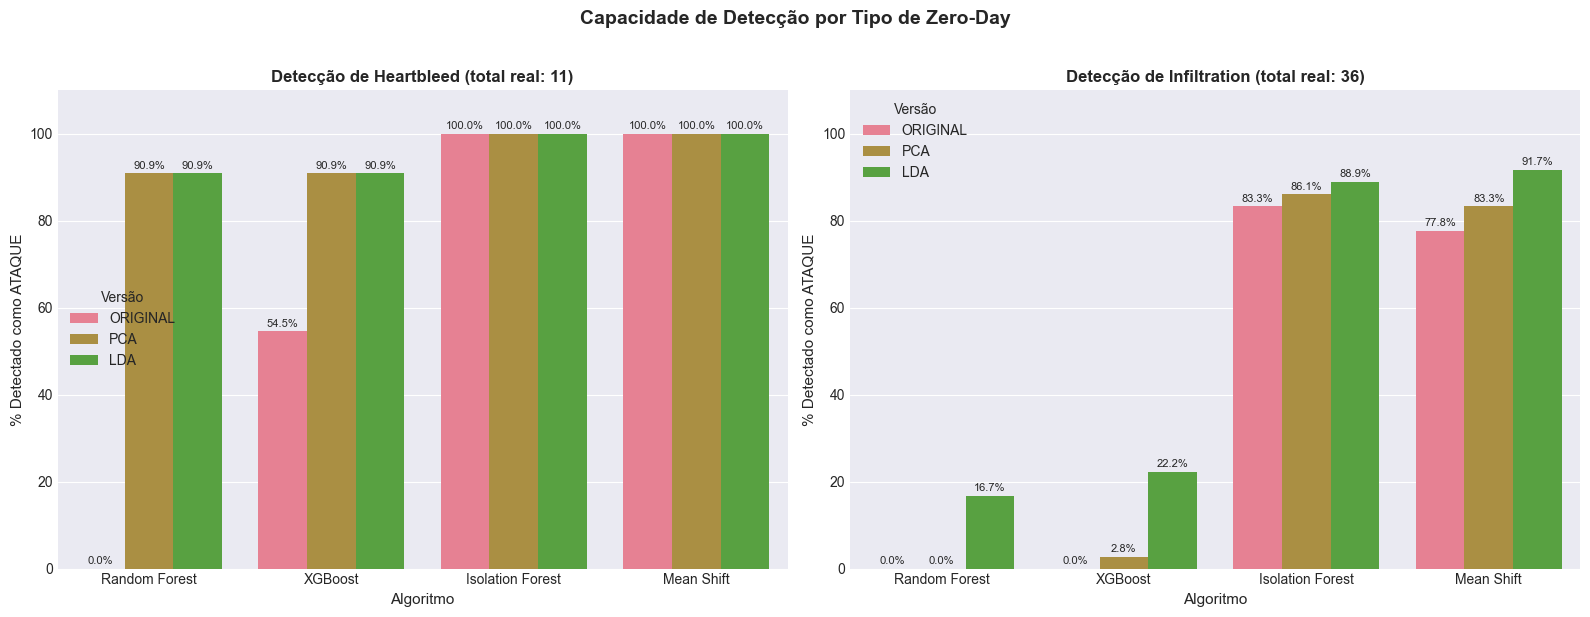

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heartbleed
sns.barplot(data=df_classe, x='Algoritmo', y='Heartbleed (%)',
            hue='Versão', ax=axes[0],
            hue_order=['ORIGINAL', 'PCA', 'LDA'],
            order=['Random Forest', 'XGBoost', 'Isolation Forest', 'Mean Shift'])
axes[0].set_title(f'Detecção de Heartbleed (total real: {total_heart})',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('% Detectado como ATAQUE', fontsize=11)
axes[0].set_xlabel('Algoritmo', fontsize=11)
axes[0].set_ylim(0, 110)
axes[0].legend(title='Versão')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', fontsize=8, padding=2)

# Infiltration
sns.barplot(data=df_classe, x='Algoritmo', y='Infiltration (%)',
            hue='Versão', ax=axes[1],
            hue_order=['ORIGINAL', 'PCA', 'LDA'],
            order=['Random Forest', 'XGBoost', 'Isolation Forest', 'Mean Shift'])
axes[1].set_title(f'Detecção de Infiltration (total real: {total_infil})',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Detectado como ATAQUE', fontsize=11)
axes[1].set_xlabel('Algoritmo', fontsize=11)
axes[1].set_ylim(0, 110)
axes[1].legend(title='Versão')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', fontsize=8, padding=2)

plt.suptitle('Capacidade de Detecção por Tipo de Zero-Day',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

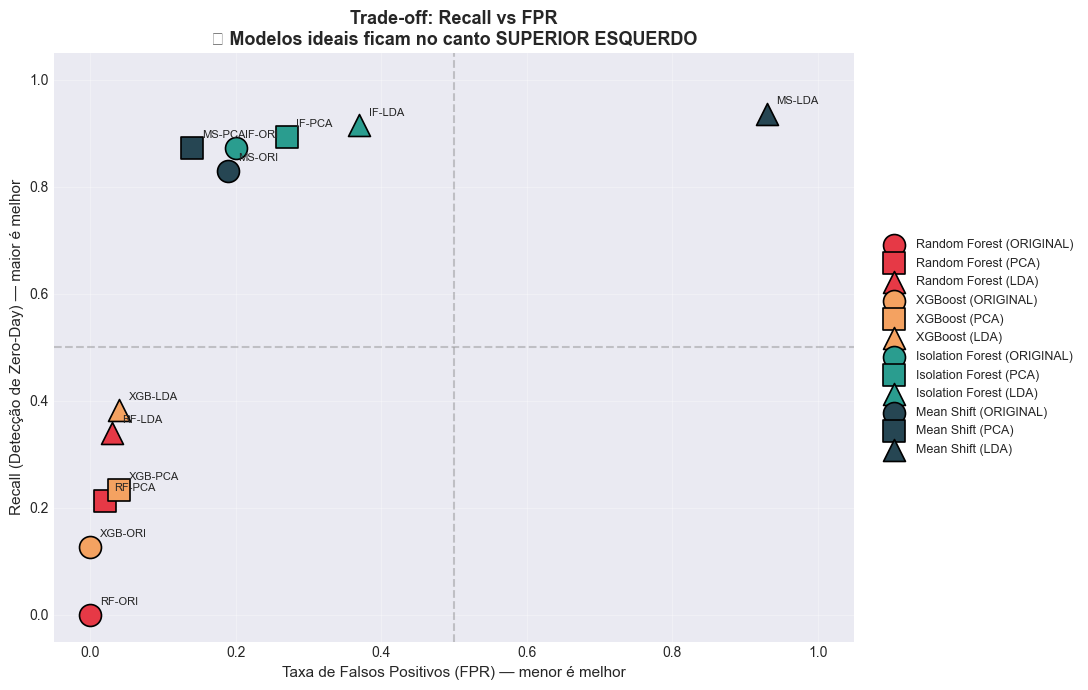

In [15]:
fig, ax = plt.subplots(figsize=(11, 7))

cores = {'RF': '#E63946', 'XGB': '#F4A261', 'IF': '#2A9D8F', 'MS': '#264653'}
marcadores = {'original': 'o', 'pca': 's', 'lda': '^'}

for _, row in df_metricas.iterrows():
    alg_abrev = row['Algoritmo']
    ver = row['Versão'].lower()
    ax.scatter(row['FPR'], row['Recall'],
               c=cores[alg_abrev], marker=marcadores[ver],
               s=250, edgecolors='black', linewidth=1.2,
               label=f"{row['Algoritmo_Completo']} ({row['Versão']})")
    ax.annotate(f"{alg_abrev}-{ver[:3].upper()}",
                (row['FPR'], row['Recall']),
                xytext=(7, 7), textcoords='offset points', fontsize=8)

ax.set_xlabel('Taxa de Falsos Positivos (FPR) — menor é melhor', fontsize=11)
ax.set_ylabel('Recall (Detecção de Zero-Day) — maior é melhor', fontsize=11)
ax.set_title('Trade-off: Recall vs FPR\n🎯 Modelos ideais ficam no canto SUPERIOR ESQUERDO',
             fontsize=13, fontweight='bold')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
pasta_saida = '../dados/dados_processados/zero_day/'
os.makedirs(pasta_saida, exist_ok=True)

# salvando métricas completas
caminho_metricas = os.path.join(pasta_saida, 'metricas_zero_day.csv')
df_metricas.to_csv(caminho_metricas, index=False)

# salvando ranking
caminho_ranking = os.path.join(pasta_saida, 'ranking_zero_day.csv')
ranking.to_csv(caminho_ranking)

# salvando detecção por classe
caminho_classe = os.path.join(pasta_saida, 'deteccao_por_classe.csv')
df_classe.to_csv(caminho_classe, index=False)

print("Arquivos salvos com sucesso ✅\n")
print("=" * 70)
print(f"  [Métricas]   {caminho_metricas}")
print(f"               Shape: {df_metricas.shape}\n")
print(f"  [Ranking]    {caminho_ranking}")
print(f"               Shape: {ranking.shape}\n")
print(f"  [Por classe] {caminho_classe}")
print(f"               Shape: {df_classe.shape}")
print("=" * 70)

Arquivos salvos com sucesso ✅

  [Métricas]   ../dados/dados_processados/zero_day/metricas_zero_day.csv
               Shape: (12, 14)

  [Ranking]    ../dados/dados_processados/zero_day/ranking_zero_day.csv
               Shape: (12, 14)

  [Por classe] ../dados/dados_processados/zero_day/deteccao_por_classe.csv
               Shape: (12, 7)


In [17]:
print("=" * 75)
print("       RESUMO DA AVALIAÇÃO COMPARATIVA EM ZERO-DAY (7.4)")
print("=" * 75)

print(f"\n Amostras avaliadas:          {len(df_predicoes)}")
print(f"   • BENIGNO:                  {(y_real_bin==0).sum()}")
print(f"   • ATAQUE (Heartbleed+Inf):  {(y_real_bin==1).sum()}")

print(f"\n Modelos avaliados:           12")

# top 3
print(f"\n 🏆 TOP 3 MODELOS (por F1-Score):")
for i, (_, row) in enumerate(ranking.head(3).iterrows(), 1):
    medalha = ['🥇', '🥈', '🥉'][i-1]
    print(f"   {medalha} {row['Algoritmo_Completo']:18s} ({row['Versão']:8s}) → "
          f"F1={row['F1-Score']:.4f} | Recall={row['Recall']:.4f} | "
          f"Prec={row['Precisão']:.4f} | FPR={row['FPR']:.4f}")

# piores
print(f"\n ⚠️  PIORES 3 MODELOS (por F1-Score):")
for i, (_, row) in enumerate(ranking.tail(3).iterrows(), 1):
    print(f"   • {row['Algoritmo_Completo']:18s} ({row['Versão']:8s}) → "
          f"F1={row['F1-Score']:.4f} | Recall={row['Recall']:.4f} | "
          f"Prec={row['Precisão']:.4f} | FPR={row['FPR']:.4f}")

# médias por categoria
print(f"\n 📊 Médias por categoria de algoritmo:")
df_metricas['Categoria'] = df_metricas['Algoritmo'].apply(
    lambda x: 'Supervisionado' if x in ['RF', 'XGB'] else 'Não-Supervisionado'
)
medias_cat = df_metricas.groupby('Categoria')[['Recall','Precisão','F1-Score','FPR']].mean()
print(medias_cat.round(4).to_string())

# médias por versão de dados
print(f"\n 📊 Médias por versão dos dados:")
medias_ver = df_metricas.groupby('Versão')[['Recall','Precisão','F1-Score','FPR']].mean()
print(medias_ver.round(4).to_string())

print("\n" + "=" * 75)
print(" Saídas: metricas_zero_day.csv | ranking_zero_day.csv | "
      "deteccao_por_classe.csv")
print("=" * 75)

       RESUMO DA AVALIAÇÃO COMPARATIVA EM ZERO-DAY (7.4)

 Amostras avaliadas:          147
   • BENIGNO:                  100
   • ATAQUE (Heartbleed+Inf):  47

 Modelos avaliados:           12

 🏆 TOP 3 MODELOS (por F1-Score):
   🥇 Mean Shift         (PCA     ) → F1=0.8039 | Recall=0.8723 | Prec=0.7455 | FPR=0.1400
   🥈 Isolation Forest   (ORIGINAL) → F1=0.7593 | Recall=0.8723 | Prec=0.6721 | FPR=0.2000
   🥉 Mean Shift         (ORIGINAL) → F1=0.7429 | Recall=0.8298 | Prec=0.6724 | FPR=0.1900

 ⚠️  PIORES 3 MODELOS (por F1-Score):
   • Random Forest      (PCA     ) → F1=0.3390 | Recall=0.2128 | Prec=0.8333 | FPR=0.0200
   • XGBoost            (ORIGINAL) → F1=0.2264 | Recall=0.1277 | Prec=1.0000 | FPR=0.0000
   • Random Forest      (ORIGINAL) → F1=0.0000 | Recall=0.0000 | Prec=0.0000 | FPR=0.0000

 📊 Médias por categoria de algoritmo:
                    Recall  Precisão  F1-Score     FPR
Categoria                                             
Não-Supervisionado  0.8865    0.5929    0.6

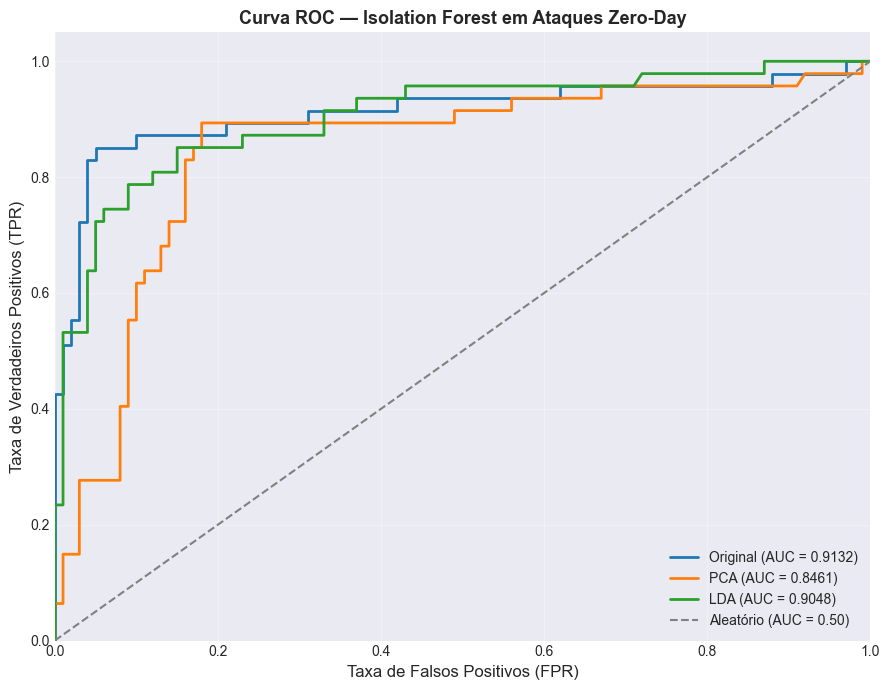

Scores utilizados: -model.score_samples(X) — quanto menor, mais anômalo


In [18]:
# ============================================================
# Curva ROC — Isolation Forest em Ataques Zero-Day
# ============================================================
import joblib
from sklearn.metrics import roc_curve, auc

pasta_dados = '../dados/dados_processados/zero_day/'
pasta_modelos = '../modelos/'

# Carrega dados normalizados/PCA/LDA
df_norm = pd.read_csv(os.path.join(pasta_dados, 'avaliacao_normalizado.csv'))
df_pca  = pd.read_csv(os.path.join(pasta_dados, 'avaliacao_pca.csv'))
df_lda  = pd.read_csv(os.path.join(pasta_dados, 'avaliacao_lda.csv'))

# Labels binárias: BENIGN → 0, demais → 1
y_real_bin_roc = np.array([0 if l == 'BENIGN' else 1 for l in df_norm['Label']])

# Carrega modelos IF
modelos_if = {
    'Original': joblib.load(os.path.join(pasta_modelos, 'modelo_if_original.pkl')),
    'PCA':      joblib.load(os.path.join(pasta_modelos, 'modelo_if_pca.pkl')),
    'LDA':      joblib.load(os.path.join(pasta_modelos, 'modelo_if_lda.pkl')),
}

dados_if = {
    'Original': df_norm.drop(columns=['Label']).values,
    'PCA':      df_pca.drop(columns=['Label']).values,
    'LDA':      df_lda.drop(columns=['Label']).values,
}

# Calcula scores (quanto menor o score, mais anômalo)
scores_if = {}
for nome, modelo in modelos_if.items():
    scores_if[nome] = -modelo.score_samples(dados_if[nome])

# Plot
plt.figure(figsize=(9, 7))
cores = {'Original': '#1f77b4', 'PCA': '#ff7f0e', 'LDA': '#2ca02c'}

for nome in ['Original', 'PCA', 'LDA']:
    fpr, tpr, _ = roc_curve(y_real_bin_roc, scores_if[nome])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=cores[nome], lw=2,
             label=f'{nome} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--',
         label='Aleatório (AUC = 0.50)')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curva ROC — Isolation Forest em Ataques Zero-Day',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Scores utilizados: -model.score_samples(X) — quanto menor, mais anômalo')

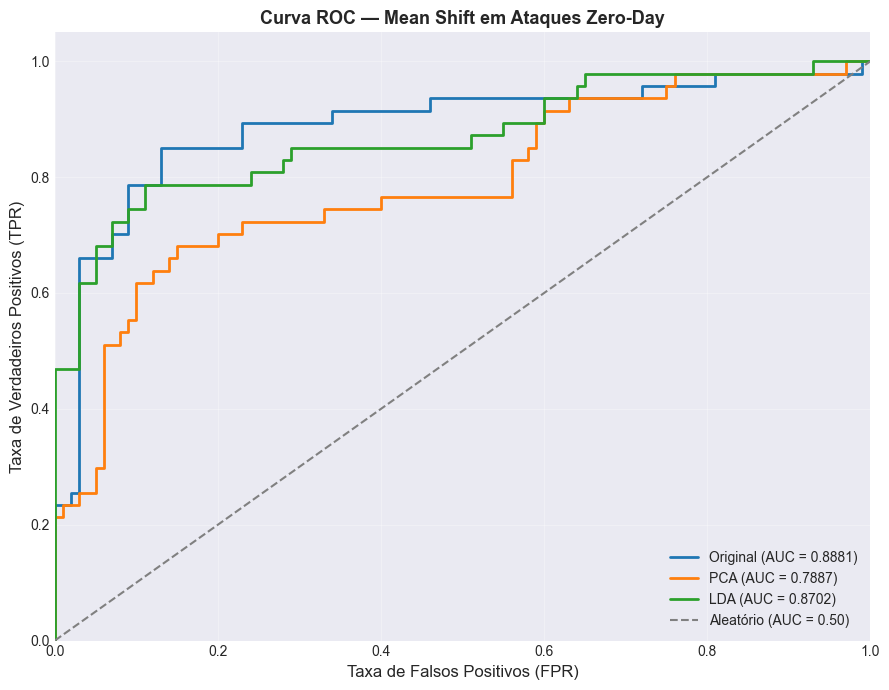

Scores utilizados: distância ao centroide mais próximo — quanto maior, mais anômalo


In [19]:
# ============================================================
# Curva ROC — Mean Shift em Ataques Zero-Day
# ============================================================
from sklearn.metrics import pairwise_distances_argmin_min
import joblib

pasta_dados = '../dados/dados_processados/zero_day/'
pasta_modelos = '../modelos/'

# Carrega dados normalizados/PCA/LDA
df_norm = pd.read_csv(os.path.join(pasta_dados, 'avaliacao_normalizado.csv'))
df_pca  = pd.read_csv(os.path.join(pasta_dados, 'avaliacao_pca.csv'))
df_lda  = pd.read_csv(os.path.join(pasta_dados, 'avaliacao_lda.csv'))

y_real_bin_roc = np.array([0 if l == 'BENIGN' else 1 for l in df_norm['Label']])

dados_ms = {
    'Original': df_norm.drop(columns=['Label']).values,
    'PCA':      df_pca.drop(columns=['Label']).values,
    'LDA':      df_lda.drop(columns=['Label']).values,
}

# Carrega modelos MS
modelos_ms = {
    'Original': joblib.load(os.path.join(pasta_modelos, 'modelo_ms_original.pkl')),
    'PCA':      joblib.load(os.path.join(pasta_modelos, 'modelo_ms_pca.pkl')),
    'LDA':      joblib.load(os.path.join(pasta_modelos, 'modelo_ms_lda.pkl')),
}

# Calcula scores (distância ao centroide do cluster mais próximo)
scores_ms = {}
for nome, modelo in modelos_ms.items():
    _, dist_min = pairwise_distances_argmin_min(dados_ms[nome], modelo.cluster_centers_)
    scores_ms[nome] = dist_min

# Plot
plt.figure(figsize=(9, 7))

for nome in ['Original', 'PCA', 'LDA']:
    fpr, tpr, _ = roc_curve(y_real_bin_roc, scores_ms[nome])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=cores[nome], lw=2,
             label=f'{nome} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--',
         label='Aleatório (AUC = 0.50)')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curva ROC — Mean Shift em Ataques Zero-Day',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Scores utilizados: distância ao centroide mais próximo — quanto maior, mais anômalo')